# Tourist Arrival Prediction with a Random Split

This experiment randomly divides individual rows into training, validation, and test sets. It is intended for comparison with the chronological split in `main.ipynb`. Because rows from the same year and month share economic and weather values, these results may be optimistic and should not be presented as true future-forecasting performance.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Load and prepare the data

In [2]:
df = pd.read_csv('touristData.csv')

month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
month_mapping = {month: number for number, month in enumerate(month_order, start=1)}

X = df.drop(columns=['totalCount']).copy()
y = df['totalCount'].copy()
X['month'] = X['month'].map(month_mapping)

categorical_features = ['month', 'originCountry']
numerical_features = [col for col in X.columns if col not in categorical_features]

print('Rows:', len(df))
print('Features:', X.shape[1])
df.head()

Rows: 750
Features: 12


,year,month,originCountry,totalCount,dollarRate,apparent_temperature_mean_celcius,sunshine_duration_seconds,rain_sum_mm,precipitation_hours,num_establishments,num_rooms,AirPassengerFaresIndex,consumerPriceIndex
0,2024,January,India,34399,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,185.5
1,2024,January,Russia,31159,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,251.3
2,2024,January,United Kingdom,16665,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,130.0
3,2024,January,Germany,13593,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,117.6
4,2024,January,China,11511,315.7,30.787654,33462.04969,7.67284,7.012346,4519,55455,178.0,103.1


## 2. Random 70/15/15 split

The first split reserves 30% of rows. That portion is divided equally into validation and test sets. A fixed random seed makes the experiment reproducible.

In [3]:
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_remaining, y_remaining, test_size=0.50, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Rows': [len(X_train), len(X_validation), len(X_test)],
    'Percentage': np.array([len(X_train), len(X_validation), len(X_test)]) / len(X) * 100,
    'Minimum year': [X_train.year.min(), X_validation.year.min(), X_test.year.min()],
    'Maximum year': [X_train.year.max(), X_validation.year.max(), X_test.year.max()]
})
split_summary

,Split,Rows,Percentage,Minimum year,Maximum year
0,Train,525,70.000000,2018,2024
1,Validation,112,14.933333,2018,2024
2,Test,113,15.066667,2018,2024


## 3. Preprocessing and models

In [4]:
standard_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

polynomial_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), [col for col in X.columns if col not in ['month', 'originCountry']]),
    ('month_poly', Pipeline([
        ('scaler', StandardScaler()),
        ('polynomial', PolynomialFeatures(degree=2, include_bias=False))
    ]), ['month']),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['originCountry'])
])

models = {
    'Linear Regression': Pipeline([
        ('preprocessor', standard_preprocessor),
        ('model', LinearRegression())
    ]),
    'Polynomial Regression': Pipeline([
        ('preprocessor', polynomial_preprocessor),
        ('model', LinearRegression())
    ]),
    'Support Vector Regression': Pipeline([
        ('preprocessor', standard_preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=SVR(kernel='rbf', C=10, epsilon=0.1),
            transformer=StandardScaler()
        ))
    ])
}

## 4. Evaluation

In [5]:
def evaluate(y_true, predictions):
    mse = mean_squared_error(y_true, predictions)
    return {
        'MAE': mean_absolute_error(y_true, predictions),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2 Score': r2_score(y_true, predictions)
    }

rows = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    for split_name, X_evaluation, y_evaluation in [
        ('Random Validation', X_validation, y_validation),
        ('Random Test', X_test, y_test)
    ]:
        predictions = model.predict(X_evaluation)
        rows.append({
            'Model': model_name,
            'Split': split_name,
            **evaluate(y_evaluation, predictions)
        })

results = (
    pd.DataFrame(rows)
    .set_index(['Model', 'Split'])
    .sort_values(['Split', 'RMSE'])
)
results

,,MAE,MSE,RMSE,R2 Score
Model,Split,,,,
Support Vector Regression,Random Test,2901.559313,1.652153e+07,4064.667922,0.834687
Linear Regression,Random Test,3950.716593,3.042679e+07,5516.048050,0.695552
Polynomial Regression,Random Test,4272.560328,3.468169e+07,5889.116273,0.652978
Support Vector Regression,Random Validation,2887.231863,1.913934e+07,4374.853012,0.818152
Linear Regression,Random Validation,3893.738023,2.936184e+07,5418.656696,0.721026
Polynomial Regression,Random Validation,4128.260471,3.167440e+07,5628.001508,0.699053


## 5. Best random-split model

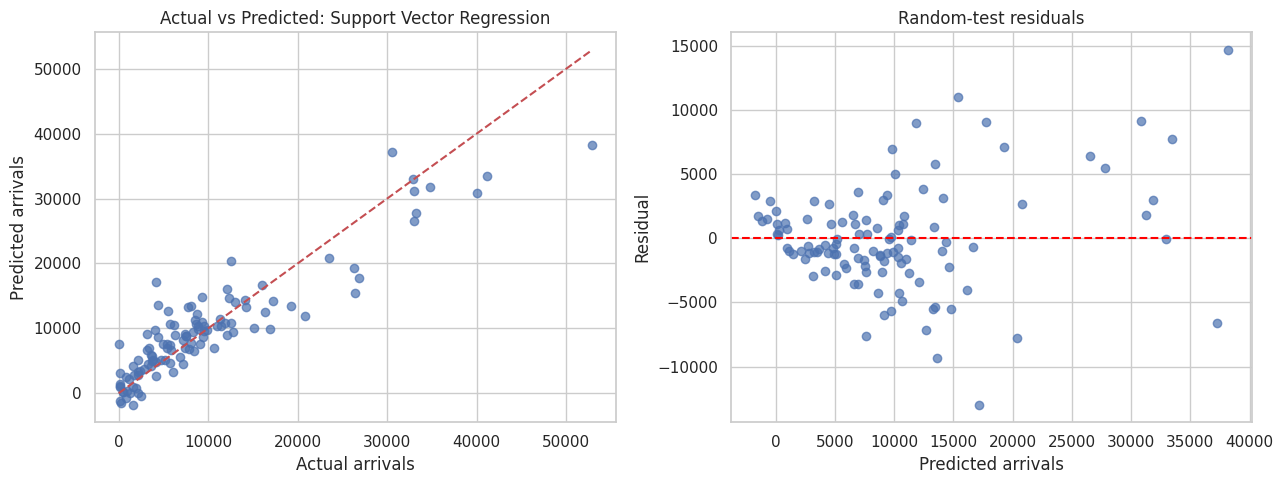

Validation-selected model: Support Vector Regression


In [6]:
validation_results = results.xs('Random Validation', level='Split')
best_model_name = validation_results['RMSE'].idxmin()
best_model = models[best_model_name]
test_predictions = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, test_predictions, alpha=0.7)
limit = max(y_test.max(), test_predictions.max())
axes[0].plot([0, limit], [0, limit], 'r--')
axes[0].set_title(f'Actual vs Predicted: {best_model_name}')
axes[0].set_xlabel('Actual arrivals')
axes[0].set_ylabel('Predicted arrivals')

residuals = y_test - test_predictions
axes[1].scatter(test_predictions, residuals, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Random-test residuals')
axes[1].set_xlabel('Predicted arrivals')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()
print('Validation-selected model:', best_model_name)

## Interpretation warning

If these scores are much better than the chronological results, the difference does not prove that the model can forecast 2024 accurately. Random splitting places observations from every year—and often the same month-year conditions—in both training and evaluation sets. Use this experiment to measure interpolation performance, while retaining the chronological split for claims about future forecasting.